# Wind Power Production Forecast Analysis - Dataset 3

## Import des modules

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from utils.datasets import load_weather_dataset

## Dataset 3: Données météo

In [ ]:
df_3 = load_weather_dataset()

In [28]:
df_3.head()

,site_name,delivery_time,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,temperature_2m,dewpoint_2m,apparent_temperature,...,snowfall,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,shortwave_radiation,direct_radiation,diffuse_radiation,weather_code,sunshine_duration
0,Belwind Phase 1,2023-01-01 00:00:00+00:00,14.603082,19.897738,218.04709,219.28940,20.7,12.25,8.85,4.282408,...,0.0,100.0,53.0,100.0,98.0,0.0,0.0,0.0,51.0,0.0
1,Belwind Phase 1,2023-01-01 01:00:00+00:00,16.182089,21.681328,215.94937,217.50421,20.8,12.10,8.80,3.290131,...,0.0,100.0,18.0,100.0,100.0,0.0,0.0,0.0,51.0,0.0
2,Belwind Phase 1,2023-01-01 02:00:00+00:00,17.969420,23.809662,226.80397,228.74626,24.1,11.85,9.50,2.291797,...,0.0,100.0,31.0,100.0,100.0,0.0,0.0,0.0,51.0,0.0
3,Belwind Phase 1,2023-01-01 03:00:00+00:00,14.792228,19.860010,227.46579,229.49266,23.9,11.80,9.85,4.007824,...,0.0,100.0,27.0,24.0,100.0,0.0,0.0,0.0,3.0,0.0
4,Belwind Phase 1,2023-01-01 04:00:00+00:00,15.001333,19.915070,227.16109,228.86830,19.7,11.75,9.30,3.694952,...,0.0,100.0,3.0,45.0,100.0,0.0,0.0,0.0,3.0,0.0


In [ ]:
df_3['delivery_time'] = pd.to_datetime(df_3['delivery_time'])

In [33]:
numerical_cols = df_3.select_dtypes(include=[np.number]).columns

In [34]:
print(df_3.isnull().sum())

site_name               0
delivery_time           0
wind_speed_10m          0
wind_speed_100m         0
wind_direction_10m      0
wind_direction_100m     0
wind_gusts_10m          0
temperature_2m          0
dewpoint_2m             0
apparent_temperature    0
pressure_msl            0
surface_pressure        0
precipitation           0
snowfall                0
cloud_cover             0
cloud_cover_low         0
cloud_cover_mid         0
cloud_cover_high        0
shortwave_radiation     0
direct_radiation        0
diffuse_radiation       0
weather_code            0
sunshine_duration       0
dtype: int64


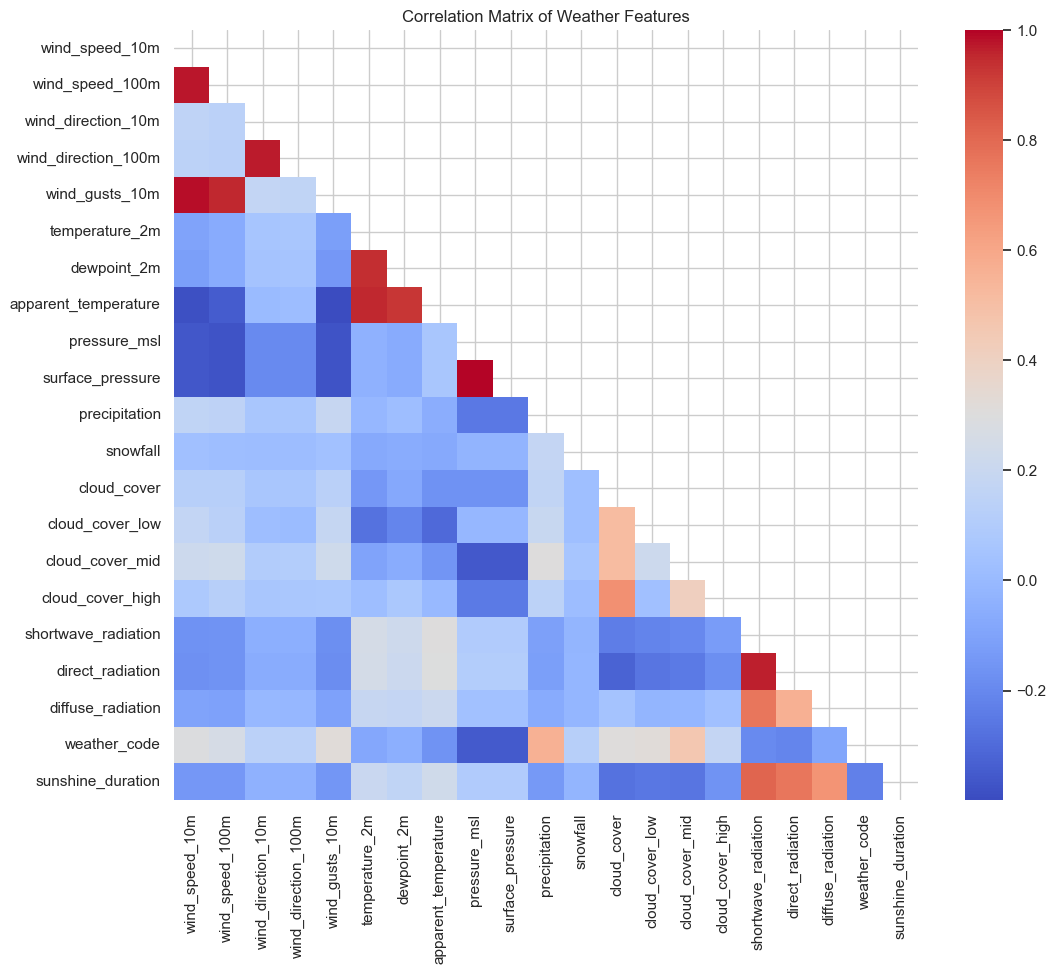

In [35]:
plt.figure(figsize=(12, 10))
corr = df_3[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Weather Features')
plt.show()

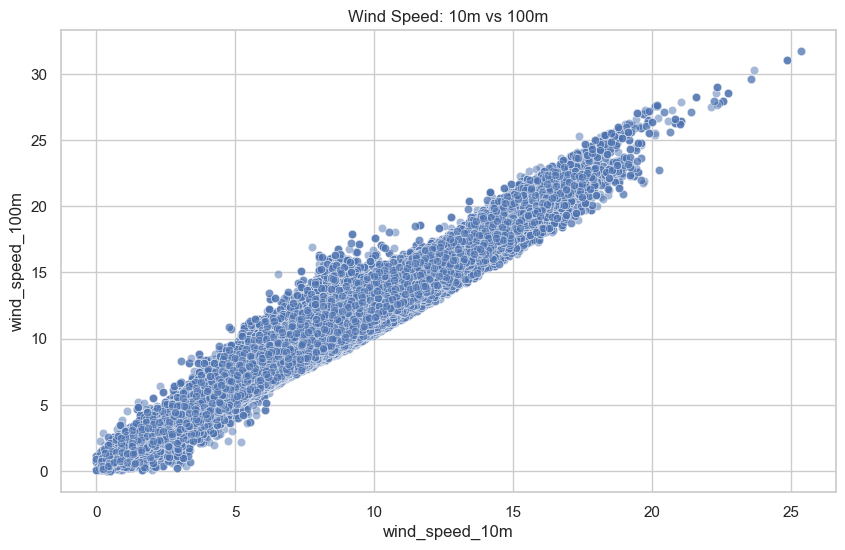

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_3, x='wind_speed_10m', y='wind_speed_100m', alpha=0.5)
plt.title('Wind Speed: 10m vs 100m')
plt.show()

In [ ]:
fig = px.line(
        df_1, 
        x='delivery_time', 
        y='production', 
        color='site_name',
        title='Production Time Series by Site',
        labels={'delivery_time': 'Time', 'production': 'Production (MW)'},
        template='plotly_white'
    )

fig.update_xaxes(rangeslider_visible=True)
# fig.update_traces(mode='lines+markers')

fig.show()

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df_3['delivery_time'], df_3['temperature_2m'], label='Actual Temp')
plt.plot(df_3['delivery_time'], df_3['apparent_temperature'], label='Apparent Temp', alpha=0.7)
plt.legend()
plt.title('Temperature Trends')
plt.xticks(rotation=45)
plt.show()

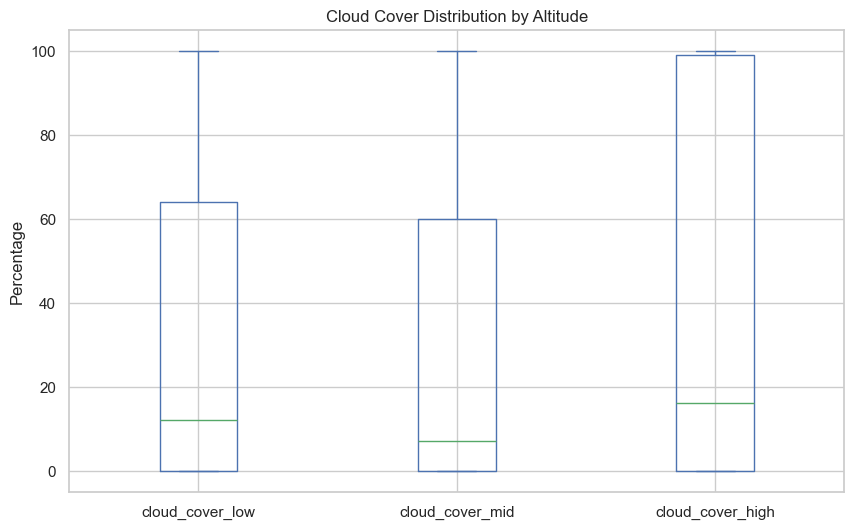

In [43]:
cloud_cols = ['cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high']
df_3[cloud_cols].plot(kind='box', figsize=(10, 6))
plt.title('Cloud Cover Distribution by Altitude')
plt.ylabel('Percentage')
plt.show()